# Creating and Populating Graphs in Neo4j 
## Design Patterns and Refactoring

In this exercise, we move beyond basic graph creation and explore **how query patterns influence your graph design**. Unlike relational databases where the schema is fixed before application development, graph database design is iterative and driven by the questions you want to answer.

Recall that graph databases treat **connections between entities as first-class data**. Relationships are stored directly — they have direction, type, and can carry properties of their own. This is fundamentally different from relational databases (where relationships are implied via JOINs) or document databases (where relationships are handled through embedding or manual lookups).

Key concepts we will review include:
1. **Graph Data Modeling**: Understanding nodes, relationships, and properties
2. **Design Patterns**: Common patterns for different use cases (simple, hub nodes, intermediate nodes, denormalized, and batch patterns)
3. **Query-Driven Design**: How your queries should shape your model — graph query performance is proportional to traversal length, not table size
4. **Normalization vs. Denormalization**: When to split data into more nodes vs. collapsing information into properties
5. **Refactoring**: Improving your graph as requirements change — graphs naturally extend without schema migrations
6. **Relationship Types**: Why specifying descriptive relationship types matters for readability and maintainability

By the end of this exercise, you'll understand how to design scalable graph databases that perform efficiently for your specific use cases.

## Step 1: Setup and Connection

Let's establish our connection to Neo4j and prepare for a deeper dive into graph modeling.

In [1]:
%%capture

# Import required libraries
from neo4j import GraphDatabase
from neo4j.exceptions import ServiceUnavailable
import time
import pandas as pd
import json
from datetime import datetime, timedelta
import random

# Driver setup - connect to Neo4j instance
URI = "bolt://127.0.0.1:7687"
AUTH = ("neo4j", "neo4jpass")

# Create driver
driver = GraphDatabase.driver(URI, auth=AUTH, notifications_min_severity="OFF")

# Test connection
try:
    with driver.session() as session:
        session.run("RETURN 1")
    print("Successfully connected to Neo4j")
except ServiceUnavailable:
    print("Could not connect to Neo4j. Make sure the service is running.")
    driver.close()

## Step 2: Understanding Graph Data Model Design Principles

Before we build a graph, let's understand the key design principles.

First, let's consider the key elements of a graph: **Nodes, Relationships, and Properties**
- **Nodes**: Represent entities — the "things in the real world" you want to query, aggregate, or connect (analogous to rows in relational databases or documents in MongoDB).
- **Relationships**: The connections between those nodes — how they interact and are related to one another. Unlike relational databases where relationships are implied and reconstructed via JOINs, graph databases store relationships directly as first-class data objects.
- **Properties**: Descriptive attributes stored on both nodes and relationships (analogous to columns in SQL or fields in a document).
- **Labels**: Classifications that describe the type of node (e.g., `Customer`, `Product`). Unlike tables or collections, labels don't determine physical storage — they're just a way to describe what kind of thing a node represents.

When working with nodes, relationships, and properties, be explicit: use descriptive relationship types (not generic "HAS" or "IS"). This helps make queries more human-readable: `(customer)-[:PURCHASED]->(product)` is better than `(customer)-[:RELATED]->(product)`.

Next, when you design your graph, ask yourself: "What questions do I want to answer?". This will help you structure your graph to make those queries efficient. The right model depends on your access patterns, not universal rules. Follow these modeling steps:

**1) Focus on the application you're building**
- Write down the key questions the system needs to answer
- What nodes are those questions about? What properties do you need?
- What relationships connect them — and what properties belong on those relationships?

**2) Prioritize representative queries**
- Sketch out a few representative queries and prioritize them
- In graph databases, query performance is proportional to the **traversal length** (number of hops), not the size of the dataset — so you want the most common paths to be efficient

**3) Determine the level of normalization**
- **Normalize** (more nodes/relationships) when: data has high cardinality, information would be duplicated across many nodes, or an entity makes sense on its own and is queried independently
- **Denormalize** (collapse into properties) when: it simplifies the model, data is always accessed together, or further normalization would significantly increase hops for common traversals
- If further normalization significantly increases the number of hops for your most common queries, that's a strong signal to denormalize instead


Depending on the answers to the above investigations, you may consider some **Common Design Patterns**:
- **Simple Patterns**: With central nodes connected directly to many others (e.g., `Customer -[:PURCHASED]-> Product`). Best for straightforward queries with few entity types.
- **Highly Normalized Graphs**: Introduce additional nodes and relationships to avoid duplication — splitting data into more granular nodes (e.g., adding `Category` or `CustomerSegment` hub nodes) so that aggregation and filtering queries become efficient.
- **Intermediate Nodes**: Create explicit nodes for junction objects that represent events or transactions (e.g., `Order` between `Customer` and `Product`, or `Batch` nodes for tracking shipments in sequence). This elevates a relationship into a first-class entity with its own properties and connections.
- **Denormalized Graphs**: Collapse information into node or relationship properties to reduce traversal hops, even if it means some duplication. Best when data is always accessed together and the number of hops for common queries matters most.
- **Batch Patterns**: Model ordered sequences of events using intermediate nodes linked in a chain (e.g., `Batch` nodes connected by `:NEXT` relationships). Useful when you need to track temporal ordering, such as "Which batch are we currently selling from?" or "Will we run out before the next batch arrives?"

Let's explore these through a real example.


## Step 3: Preparation - Clear and Load ACME Corporation Data

We'll use the ACME Corporation dataset (customers, products, purchases, ratings) to demonstrate different graph design approaches and how to refactor when requirements change.

In [2]:
# Clear all existing data
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
    print("Cleared all nodes and relationships")

Cleared all nodes and relationships


In [3]:
# Load sample ACME Corporation data
acme_data = {
    'customers': [
        {'id': 'C001', 'name': 'Alice Smith', 'email': 'alice@company.com', 'status': 'gold'},
        {'id': 'C002', 'name': 'Bob Johnson', 'email': 'bob@company.com', 'status': 'silver'},
        {'id': 'C003', 'name': 'Charlie Lee', 'email': 'charlie@company.com', 'status': 'bronze'},
        {'id': 'C004', 'name': 'Diana Prince', 'email': 'diana@company.com', 'status': 'gold'},
        {'id': 'C005', 'name': 'Eve Martinez', 'email': 'eve@company.com', 'status': 'silver'},
    ],
    'products': [
        {'id': 'P001', 'name': 'Small Gear', 'category': 'Gears', 'type': 'small', 'price': 49.99},
        {'id': 'P002', 'name': 'Large Gear', 'category': 'Gears', 'type': 'large', 'price': 149.99},
        {'id': 'P003', 'name': 'Bearing', 'category': 'Components', 'type': 'bearing', 'price': 29.99},
        {'id': 'P004', 'name': 'Shaft', 'category': 'Components', 'type': 'shaft', 'price': 39.99},
    ],
    'purchases': [
        {'customer_id': 'C001', 'product_id': 'P001', 'date': '2024-01-15', 'qty': 5},
        {'customer_id': 'C001', 'product_id': 'P003', 'date': '2024-01-20', 'qty': 10},
        {'customer_id': 'C002', 'product_id': 'P002', 'date': '2024-01-18', 'qty': 2},
        {'customer_id': 'C002', 'product_id': 'P004', 'date': '2024-02-01', 'qty': 8},
        {'customer_id': 'C003', 'product_id': 'P001', 'date': '2024-02-05', 'qty': 3},
        {'customer_id': 'C004', 'product_id': 'P001', 'date': '2024-02-10', 'qty': 7},
        {'customer_id': 'C004', 'product_id': 'P002', 'date': '2024-02-12', 'qty': 4},
        {'customer_id': 'C005', 'product_id': 'P003', 'date': '2024-02-15', 'qty': 6},
    ],
    'ratings': [
        {'customer_id': 'C001', 'product_id': 'P001', 'score': 5, 'text': 'Excellent quality'},
        {'customer_id': 'C001', 'product_id': 'P003', 'score': 4, 'text': 'Good product'},
        {'customer_id': 'C002', 'product_id': 'P002', 'score': 5, 'text': 'Perfect fit'},
        {'customer_id': 'C003', 'product_id': 'P001', 'score': 3, 'text': 'Average'},
        {'customer_id': 'C004', 'product_id': 'P001', 'score': 5, 'text': 'Great!'},
        {'customer_id': 'C004', 'product_id': 'P002', 'score': 4, 'text': 'Very good'},
    ]
}

print("ACME Corporation data loaded:")
print(f"   Customers: {len(acme_data['customers'])}")
print(f"   Products: {len(acme_data['products'])}")
print(f"   Purchases: {len(acme_data['purchases'])}")
print(f"   Ratings: {len(acme_data['ratings'])}")

ACME Corporation data loaded:
   Customers: 5
   Products: 4
   Purchases: 8
   Ratings: 6


## Step 4: Design Pattern 1 - Simple Model (Basic, Denormalized Approach)

#### Task 1: Create a simple graph model

Let's start with a straightforward denormalized graph model:
- **Customers** connect to **Products** via PURCHASED relationships
- **Customers** rate **Products** via RATED relationships
- All attributes of the nodes are stored directly as their properties.

This works well for basic queries but has limitations for complex analytics. Let's implement it and understand its strengths and weaknesses.

Complete the code segments below to get started! 

Hint: you can use the syntax: ```"CREATE (r:Record {field1: $field1, field2: $field2, ... , fieldN: $fieldN})",``` , and complete the loops that create those nodes for every record in our python datasets. 

Make sure to adjust the "record" for customers and products. Note you only have to create nodes here. We've covered relationships for you, but make sure to review that code.


In [4]:
def create_simple_model(driver, data):
    """
    Design Pattern 1: Simple / Denormalized Model
    Direct connections with data stored on relationships as properties.
    Customer -[:PURCHASED {date, quantity}]-> Product
    Customer -[:RATED {score, text}]-> Product
    
    This is a denormalized approach: data that is always accessed together
    (e.g., purchase date and quantity) is stored directly on the relationship,
    avoiding extra hops. Best for straightforward queries with few entity types.
    """
    with driver.session() as session:
        # 1. Create Customer nodes
        for customer in data['customers']:
            session.run(
                ### BEGIN SOLUTION
                "CREATE (c:Customer {id: $id, name: $name, email: $email, status: $status})",
                ### END SOLUTION
                id=customer['id'], name=customer['name'],
                email=customer['email'], status=customer['status']
            )

        # 2. Create Product nodes
        for product in data['products']:
            session.run(
                ### BEGIN SOLUTION
                "CREATE (p:Product {id: $id, name: $name, category: $category, type: $type, price: $price})",
                ### END SOLUTION
                id=product['id'], name=product['name'],
                category=product['category'], type=product['type'], price=product['price']
            )

        # 3. Create PURCHASED relationships with date and quantity as properties
        # Rich relationships: storing metadata directly on the edge (denormalization)
        for purchase in data['purchases']:
            session.run("""
                MATCH (c:Customer {id: $customer_id}), (p:Product {id: $product_id})
                CREATE (c)-[:PURCHASED {date: $date, quantity: $qty}]->(p)
            """, customer_id=purchase['customer_id'], product_id=purchase['product_id'],
                date=purchase['date'], qty=purchase['qty'])

        # 4. Create RATED relationships with score and text as properties
        for rating in data['ratings']:
            session.run("""
                MATCH (c:Customer {id: $customer_id}), (p:Product {id: $product_id})
                CREATE (c)-[:RATED {score: $score, text: $text}]->(p)
            """, customer_id=rating['customer_id'], product_id=rating['product_id'],
                score=rating['score'], text=rating['text'])

        # Print summary
        result = session.run("MATCH (n) RETURN labels(n)[0] AS type, count(*) AS count ORDER BY type")
        print("Simple (denormalized) model created:")
        for record in result:
            print(f"   {record['type']}: {record['count']}")

        result = session.run("MATCH ()-[r]->() RETURN type(r) AS type, count(*) AS count ORDER BY type")
        print("   Relationships:")
        for record in result:
            print(f"   {record['type']}: {record['count']}")

# Create the simple model
create_simple_model(driver, acme_data)

Simple (denormalized) model created:
   Customer: 5
   Product: 4
   Relationships:
   PURCHASED: 8
   RATED: 6


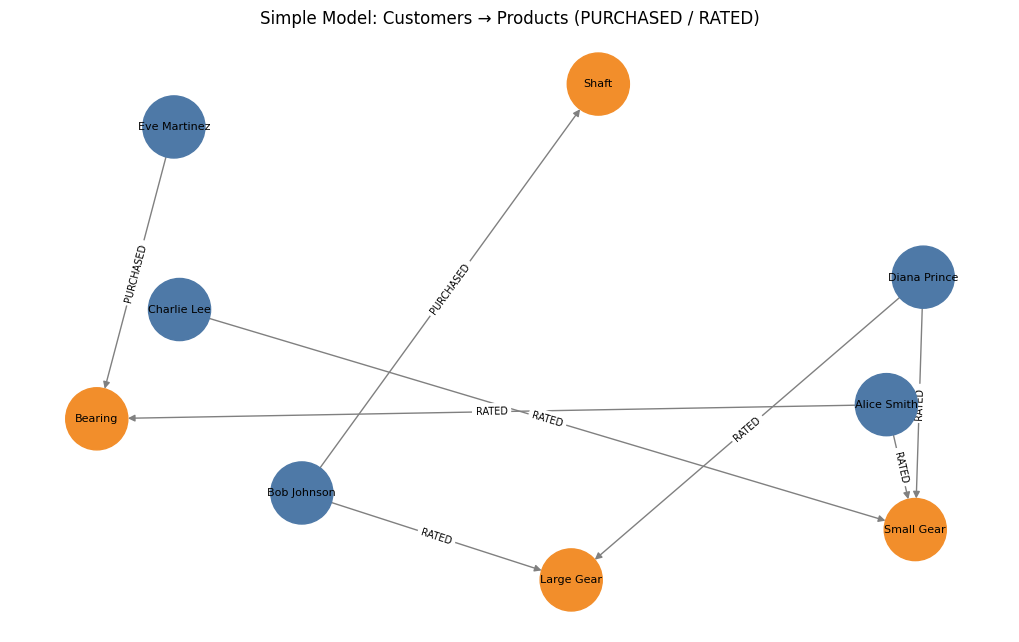

In [5]:
# Visualize the simple model
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

with driver.session() as session:
    # Add nodes
    nodes = session.run("MATCH (n) RETURN n.id AS id, n.name AS name, labels(n)[0] AS label")
    for rec in nodes:
        G.add_node(rec['id'] or rec['name'], label=rec['label'], name=rec['name'])

    # Add edges
    edges = session.run("MATCH (a)-[r]->(b) RETURN a.id AS src, b.id AS tgt, type(r) AS rel")
    for rec in edges:
        G.add_edge(rec['src'] or '', rec['tgt'] or '', rel=rec['rel'])

color_map = {'Customer': '#4e79a7', 'Product': '#f28e2b'}
colors = [color_map.get(G.nodes[n].get('label'), '#ccc') for n in G.nodes]
labels = {n: G.nodes[n].get('name', n) for n in G.nodes}
edge_labels = {(u, v): d['rel'] for u, v, d in G.edges(data=True)}

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42, k=2)
nx.draw(G, pos, labels=labels, node_color=colors, node_size=2000,
        font_size=8, arrows=True, edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("Simple Model: Customers → Products (PURCHASED / RATED)")
plt.show()

### Analysis of Simple Model

This is the most basic example of a graph — a **denormalized** approach where we collapse information directly onto nodes and relationship properties rather than splitting it into separate entities.

**Strengths:**
- Simple to understand and implement
- Great for direct traversal queries like "Who purchased what?" or "What did Alice rate?"
- Relationship properties (date, quantity, score) keep related data together — no extra hops needed
- Fewer nodes means a smaller graph to manage
- Fast to query data which is accessed together!

This maps to the **denormalization** guidance from the course: if data is always accessed together (e.g., purchase date and quantity), storing it on the relationship avoids coordination overhead and reduces traversal length.

**Weaknesses:**
- Hard to analyze trends by category — you'd need to filter by product properties rather than traversing to a category node
- Difficult to find products bought together frequently
- No explicit representation of categories or customer segments as queryable entities
- Can't efficiently aggregate by category without scanning all products
- If you need to query or aggregate by a concept (like "Gears" category), it should be its own node — not just a property

This is a classic case where the **"Properties vs. Nodes" decision** matters: if you'll query or aggregate on something, make it a node.

## Step 5: Design Pattern 2 - Enhanced Model (Hub Node Pattern / Normalization)

Now let's refactor by adding **Category** nodes and **CustomerSegment** nodes. This is the **Hub Node Pattern** — a form of **graph normalization** where we introduce additional nodes and relationships instead of repeating properties.

In graph databases, normalization means splitting data into more granular nodes so that aggregation and filtering queries become efficient. This is analogous to how normalization works in relational databases (splitting data across tables to avoid duplication), but here we're creating **hub nodes** — categorical nodes that serve as shared connection points.

**Why this matters for queries:**
- "Show me top products in the Gears category" → direct traversal to the Category hub node
- "Find gold customers" → query by the CustomerSegment hub node
- "What categories interest gold customers most?" → efficient pattern matching through hub nodes
- Without hub nodes, these queries would require filtering by property values across all Product or Customer nodes

#### Task 2: Create an enhanced, normalized model

Complete the code below to get started!

Hint: you can use the syntax ```"CREATE (c:Category {name: $name})",``` for categories, and the syntax ```"CREATE (s:CustomerSegment {name: $name})",``` for customer segments.


In [6]:
def create_enhanced_model(driver, data):
    """
    Design Pattern 2: Hub Node Pattern (Graph Normalization)
    Introduce Category and CustomerSegment as "hub" nodes —
    categorical nodes that serve as shared connection points.
    
    This is graph normalization: splitting data into more granular nodes
    so that aggregation and filtering queries become efficient.
    
    Product -[:BELONGS_TO]-> Category
    Customer -[:HAS_SEGMENT]-> CustomerSegment
    
    Benefits:
    - Category names live in one place (no duplication across Product nodes)
    - Enables efficient aggregation queries via hub traversal
    - Entities that deserve independent querying now have their own nodes
    """
    with driver.session() as session:
        # 1. Extract unique categories from products
        categories = set(p['category'] for p in data['products'])

        # 2. Extract unique customer segments (status values) from customers
        segments = set(c['status'] for c in data['customers'])

        # 3. Create Category hub nodes (normalization: category is now its own entity)
        for category in categories:
            session.run(
                ### BEGIN SOLUTION
                "CREATE (c:Category {name: $name})", 
                ### END SOLUTION
                name=category)

        # 4. Create CustomerSegment hub nodes (normalization: segment is now its own entity)
        for segment in segments:
            session.run(
                ### BEGIN SOLUTION
                "CREATE (s:CustomerSegment {name: $name})", 
                ### END SOLUTION
                name=segment
                )

        # 5. Link Products to Categories with BELONGS_TO relationships
        for product in data['products']:
            session.run("""
                MATCH (p:Product {id: $id}), (c:Category {name: $category})
                CREATE (p)-[:BELONGS_TO]->(c)
            """, id=product['id'], category=product['category'])

        # 6. Link Customers to CustomerSegments with HAS_SEGMENT relationships
        for customer in data['customers']:
            session.run("""
                MATCH (c:Customer {id: $id}), (s:CustomerSegment {name: $status})
                CREATE (c)-[:HAS_SEGMENT]->(s)
            """, id=customer['id'], status=customer['status'])

        print("Enhanced model with hub nodes created (graph normalization)")
        print(f"   Category hub nodes: {categories}")
        print(f"   CustomerSegment hub nodes: {segments}")

# Add hub nodes on top of existing simple model (normalization layer)
create_enhanced_model(driver, acme_data)

Enhanced model with hub nodes created (graph normalization)
   Category hub nodes: {'Components', 'Gears'}
   CustomerSegment hub nodes: {'bronze', 'gold', 'silver'}


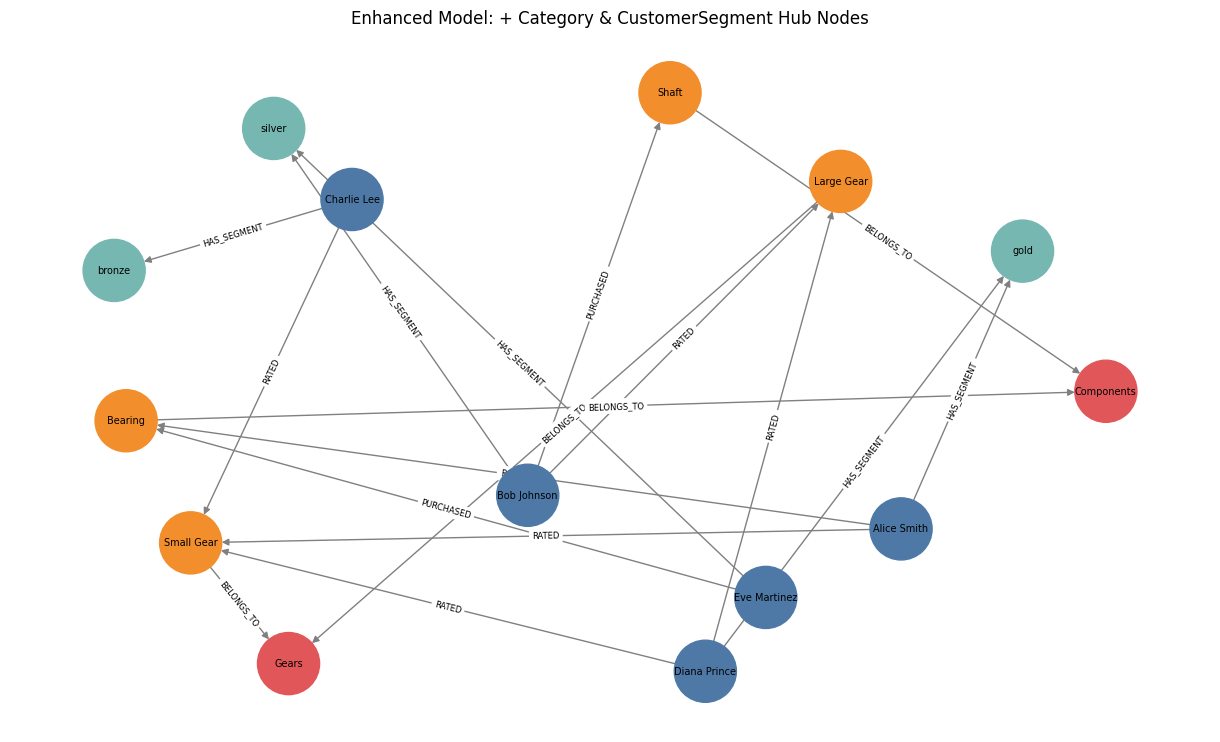

In [7]:
# Visualize the enhanced model with hub nodes
G = nx.DiGraph()

with driver.session() as session:
    nodes = session.run("MATCH (n) RETURN coalesce(n.id, n.name) AS id, n.name AS name, labels(n)[0] AS label")
    for rec in nodes:
        G.add_node(rec['id'], label=rec['label'], name=rec['name'])

    edges = session.run("""
        MATCH (a)-[r]->(b)
        RETURN coalesce(a.id, a.name) AS src, coalesce(b.id, b.name) AS tgt, type(r) AS rel
    """)
    for rec in edges:
        G.add_edge(rec['src'], rec['tgt'], rel=rec['rel'])

color_map = {'Customer': '#4e79a7', 'Product': '#f28e2b', 'Category': '#e15759', 'CustomerSegment': '#76b7b2'}
colors = [color_map.get(G.nodes[n].get('label'), '#ccc') for n in G.nodes]
labels = {n: G.nodes[n].get('name', n) for n in G.nodes}
edge_labels = {(u, v): d['rel'] for u, v, d in G.edges(data=True)}

plt.figure(figsize=(12, 7))
pos = nx.spring_layout(G, seed=42, k=2)
nx.draw(G, pos, labels=labels, node_color=colors, node_size=2000,
        font_size=7, arrows=True, edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.title("Enhanced Model: + Category & CustomerSegment Hub Nodes")
plt.show()

### Analysis of Enhanced Model with Hub Nodes

By normalizing our graph with hub nodes, we've made a key trade-off: slightly more structure in exchange for significantly more powerful queries.

**New Capabilities (Normalization Benefits):**
- Can now efficiently query "What are the top-rated products in category X?" — start at the Category node and traverse directly
- Can find "Which categories do gold customers prefer?" — traverse from CustomerSegment → Customers → Products → Categories
- Hub nodes make aggregation queries much faster because they act as shared connection points
- Clear separation of concerns — entities that deserve independent querying (categories, segments) now have their own nodes
- Reduces risk of inconsistency: category names live in one place rather than being duplicated as properties across many Product nodes

**Trade-offs (Normalization Costs):**
- Slightly more complex graph structure with additional node types
- More nodes and relationships to maintain
- Additional hops required for some traversals (e.g., getting a product's category now requires one extra hop)

This is a good example of the normalization guidance from the course: **if the same information would be duplicated across many nodes, normalization reduces the risk of inconsistency**. And **if an entity makes sense on its own and is queried independently, it likely deserves its own place in the graph**.

## Step 6: Intermediate Nodes — Elevating Relationships to First-Class Entities

One of the powerful features of graphs is the ability to store data on relationships (rich relationships), not just nodes. But sometimes a relationship carries so much information that it deserves to become its own **intermediate node**.

An intermediate node is created when a relationship has enough properties and connections that it starts being its own record — it has properties and connects to other nodes independently.

**When to use intermediate nodes:**
- When an event or transaction (like an Order) needs to connect to multiple other entities
- When you need to track status, fulfillment, or other evolving properties on what was originally "just a connection"
- When the same concept appears in ordered sequences (like Batches arriving over time)

**The pattern shift:**
- **Before**: `Customer -[:PURCHASED {quantity, date}]-> Product` (data lives on the relationship)
- **After**: `Customer -[:PLACED]-> Order -[:CONTAINS]-> Product` (Order becomes a first-class entity)

This is particularly useful for **Batch Patterns** as well — when real-world business processes are ordered in sequence (e.g., shipments arriving in batches), intermediate batch nodes linked in a chain can answer questions like "Which batch are we currently selling from?" or "Will stock run out before the next batch arrives?"

In [8]:
def add_order_nodes(driver, data):
    """
    Design Pattern 3: Intermediate Nodes (Orders)
    Elevates a relationship into a first-class entity with its own
    properties and connections.
    
    Before (denormalized): Customer -[:PURCHASED {quantity, date}]-> Product
    After (intermediate):  Customer -[:PLACED]-> Order -[:CONTAINS]-> Product
    
    Benefits:
    - Order becomes a first-class entity that can connect to other nodes
      (payments, shipments, returns) independently
    - Can track order status, fulfillment, and other evolving properties
    - Can query "which orders contain multiple products?"
    - Enables co-occurrence analysis (products bought together in same order)
    
    This pattern is also the basis for Batch Patterns — ordered sequences
    of intermediate nodes linked in a chain (e.g., Batch -[:NEXT]-> Batch).
    """
    with driver.session() as session:
        for i, purchase in enumerate(data['purchases'], 1):
            order_id = f"ORD{i:04d}"
            session.run("""
                MATCH (c:Customer {id: $customer_id}), (p:Product {id: $product_id})
                CREATE (o:Order {id: $order_id, date: $date})
                CREATE (c)-[:PLACED]->(o)
                CREATE (o)-[:CONTAINS {quantity: $qty}]->(p)
            """, customer_id=purchase['customer_id'], product_id=purchase['product_id'],
                order_id=order_id, date=purchase['date'], qty=purchase['qty'])

        print(f"Created {len(data['purchases'])} Order intermediate nodes")
        result = session.run("MATCH (o:Order) RETURN count(o) AS count")
        print(f"   Total Orders in graph: {result.single()['count']}")

# Add Order intermediate nodes
add_order_nodes(driver, acme_data)

Created 8 Order intermediate nodes
   Total Orders in graph: 8


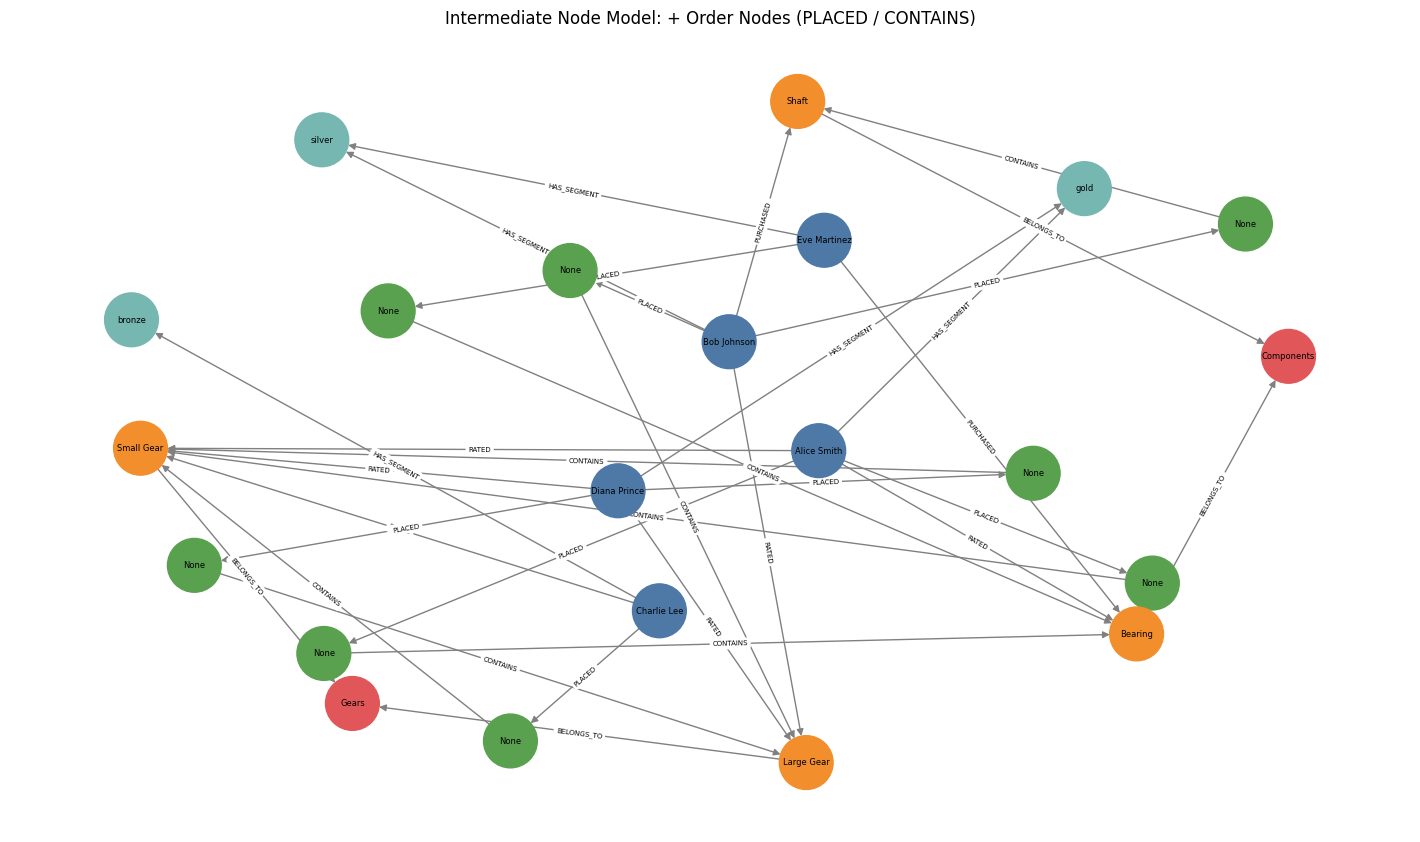

In [9]:
# Visualize the model with Order intermediate nodes
G = nx.DiGraph()

with driver.session() as session:
    nodes = session.run("MATCH (n) RETURN coalesce(n.id, n.name) AS id, n.name AS name, labels(n)[0] AS label")
    for rec in nodes:
        G.add_node(rec['id'], label=rec['label'], name=rec['name'])

    edges = session.run("""
        MATCH (a)-[r]->(b)
        RETURN coalesce(a.id, a.name) AS src, coalesce(b.id, b.name) AS tgt, type(r) AS rel
    """)
    for rec in edges:
        G.add_edge(rec['src'], rec['tgt'], rel=rec['rel'])

color_map = {'Customer': '#4e79a7', 'Product': '#f28e2b', 'Category': '#e15759',
             'CustomerSegment': '#76b7b2', 'Order': '#59a14f'}
colors = [color_map.get(G.nodes[n].get('label'), '#ccc') for n in G.nodes]
labels = {n: G.nodes[n].get('name', n) for n in G.nodes}
edge_labels = {(u, v): d['rel'] for u, v, d in G.edges(data=True)}

plt.figure(figsize=(14, 8))
pos = nx.spring_layout(G, seed=42, k=1.5)
nx.draw(G, pos, labels=labels, node_color=colors, node_size=1500,
        font_size=6, arrows=True, edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=5)
plt.title("Intermediate Node Model: + Order Nodes (PLACED / CONTAINS)")
plt.show()

### Intermediate Node Benefits

By promoting `Order` from a relationship to a node, we've unlocked sophisticated query patterns:
- "Find customers who ordered multiple products in a single order"
- "Which products are frequently ordered together?" (co-occurrence within orders)
- "Find the most recent order from each customer"
- "Track order status and fulfillment separately from the original purchase"

**Why this matters:** The Order node can now have its own relationships to other entities — payments, shipments, returns — without overloading a single relationship with too many properties. As the course teaches, when a relationship has enough information that it "starts being its own record," it deserves to be an intermediate node.

**Batch extension:** If orders arrived in batches, we could further add `Batch` intermediate nodes chained with `:NEXT` relationships to track temporal ordering — enabling questions like "Which batch did a customer's order come from?" or "Will we run out of stock before the next batch arrives?"

## Step 7: Demonstrating Query-Driven Design

Now let's show why our design choices matter by querying the enhanced model.

#### Task 3: Query by Category Hub

Find all products in a category and their average rating.

In [10]:
# Efficient category query - hub pattern makes this fast
### BEGIN SOLUTION
category_query = """
MATCH (cat:Category {name: 'Gears'})<-[:BELONGS_TO]-(p:Product)
OPTIONAL MATCH (p)<-[r:RATED]-()
RETURN p.name AS product, p.price AS price,
       avg(r.score) AS avg_rating, count(r) AS num_reviews
ORDER BY avg_rating DESC
"""
### END SOLUTION

with driver.session() as session:
    result = session.run(category_query)
    records = list(result)
    if records:
        df = pd.DataFrame([record.values() for record in records], columns=records[0].keys())
        print("Products in 'Gears' Category with Ratings:")
        print(df)
    else:
        print("No results - check your query")

Products in 'Gears' Category with Ratings:
      product   price  avg_rating  num_reviews
0  Large Gear  149.99    4.500000            2
1  Small Gear   49.99    4.333333            3


#### Task 4: Customer Segment Analysis

Find the purchasing patterns of different customer segments.

In [11]:
# Find which categories each segment purchases from
### BEGIN SOLUTION
segment_analysis_query = """
MATCH (seg:CustomerSegment {name: 'gold'})<-[:HAS_SEGMENT]-(c:Customer)
      -[:PLACED]->(o:Order)-[cont:CONTAINS]->(p:Product)
      -[:BELONGS_TO]->(cat:Category)
RETURN cat.name AS category,
       count(DISTINCT c) AS unique_customers,
       sum(cont.quantity) AS total_quantity
ORDER BY total_quantity DESC
"""
### END SOLUTION

with driver.session() as session:
    result = session.run(segment_analysis_query)
    records = list(result)
    if records:
        df = pd.DataFrame([record.values() for record in records], columns=records[0].keys())
        print("Gold Customer Segment Analysis:")
        print(df)
    else:
        print("No results - check your query")

Gold Customer Segment Analysis:
     category  unique_customers  total_quantity
0       Gears                 2              16
1  Components                 1              10


#### Task 5: Product Affinity (Products Bought Together)

Find products that are frequently purchased together using the Order intermediate node pattern.

In [12]:
# Product affinity using the Order intermediate node pattern
# This traverses: Customer -[:PLACED]-> Order -[:CONTAINS]-> Product
# to find products purchased by the same customer via their orders
### BEGIN SOLUTION
affinity_query = """
MATCH (c:Customer)-[:PLACED]->(o:Order)-[:CONTAINS]->(p1:Product),
      (c)-[:PLACED]->(o2:Order)-[:CONTAINS]->(p2:Product)
WHERE p1.id < p2.id
RETURN p1.name AS product1, p2.name AS product2,
       count(DISTINCT c) AS shared_customers
ORDER BY shared_customers DESC
"""
### END SOLUTION

with driver.session() as session:
    result = session.run(affinity_query)
    records = list(result)
    if records:
        df = pd.DataFrame([record.values() for record in records], columns=records[0].keys())
        print("Product Affinity Analysis (Bought Together via Orders):")
        print(df)
    else:
        print("No co-purchases found")

Product Affinity Analysis (Bought Together via Orders):
     product1    product2  shared_customers
0  Small Gear     Bearing                 1
1  Large Gear       Shaft                 1
2  Small Gear  Large Gear                 1


#### Task 6: Customer Lifetime Value

Calculate total spending and order count per customer using the Order and Product relationship structure.

In [13]:
# Customer Lifetime Value calculation
### BEGIN SOLUTION
clv_query = """
MATCH (c:Customer)-[:HAS_SEGMENT]->(seg:CustomerSegment)
MATCH (c)-[:PLACED]->(o:Order)-[cont:CONTAINS]->(p:Product)
RETURN c.name AS customer, seg.name AS segment,
       count(DISTINCT o) AS num_orders,
       sum(p.price * cont.quantity) AS total_spent
ORDER BY total_spent DESC
"""
### END SOLUTION

with driver.session() as session:
    result = session.run(clv_query)
    records = list(result)
    if records:
        df = pd.DataFrame([record.values() for record in records], columns=records[0].keys())
        print("Customer Lifetime Value Analysis:")
        print(df)
    else:
        print("No results")

Customer Lifetime Value Analysis:
       customer segment  num_orders  total_spent
0  Diana Prince    gold           2       949.89
1   Bob Johnson  silver           2       619.90
2   Alice Smith    gold           2       549.85
3  Eve Martinez  silver           1       179.94
4   Charlie Lee  bronze           1       149.97


## Step 8: Refactoring — Adding New Requirements

Real-world systems evolve. One of the key advantages of graph databases over relational systems is that **structure changes happen through regular graph operations, not a separate schema migration step**. There's no need to run an `ALTER TABLE`-style command — you simply add new nodes, relationships, and properties as requirements emerge.

Graph databases use a **flexible data model**: nodes and relationships can have properties added, changed, or removed at any time, and different nodes of the same type don't need to share the same structure. Structure emerges as data is created and updated.

Let's demonstrate this by adding a new requirement: **Suppliers** — products have suppliers, and we want to analyze supplier relationships. We'll add `Supplier` nodes and `SUPPLIED_BY` relationships without modifying any existing data.

In [14]:
def add_supplier_network(driver):
    """
    Refactoring: Add Supplier nodes and SUPPLIED_BY relationships.
    
    Demonstrates graph database flexibility — structure changes happen
    through regular graph operations (CREATE), not ALTER TABLE-style
    schema migrations. We add new node types and relationships without
    modifying any existing data.
    
    Product -[:SUPPLIED_BY]-> Supplier
    
    This also serves as another hub node (normalization): suppliers
    are shared connection points that enable supplier-based analytics.
    """
    suppliers = [
        {'id': 'S001', 'name': 'GearWorks Inc.'},
        {'id': 'S002', 'name': 'ComponentCo Ltd.'},
    ]

    product_suppliers = {
        'P001': 'S001', 'P002': 'S001',  # Gears from GearWorks
        'P003': 'S002', 'P004': 'S002',  # Components from ComponentCo
    }

    with driver.session() as session:
        # Create Supplier nodes — no schema change needed, just CREATE
        for supplier in suppliers:
            session.run(
                "CREATE (s:Supplier {id: $id, name: $name})",
                id=supplier['id'], name=supplier['name']
            )

        # Link Products to Suppliers with descriptive SUPPLIED_BY relationship type
        for product_id, supplier_id in product_suppliers.items():
            session.run("""
                MATCH (p:Product {id: $pid}), (s:Supplier {id: $sid})
                CREATE (p)-[:SUPPLIED_BY]->(s)
            """, pid=product_id, sid=supplier_id)

        print("Supplier network added (graph extended without schema migration)")
        print(f"   Suppliers: {[s['name'] for s in suppliers]}")

# Add supplier network — demonstrates refactoring / flexible data model
add_supplier_network(driver)

Supplier network added (graph extended without schema migration)
   Suppliers: ['GearWorks Inc.', 'ComponentCo Ltd.']


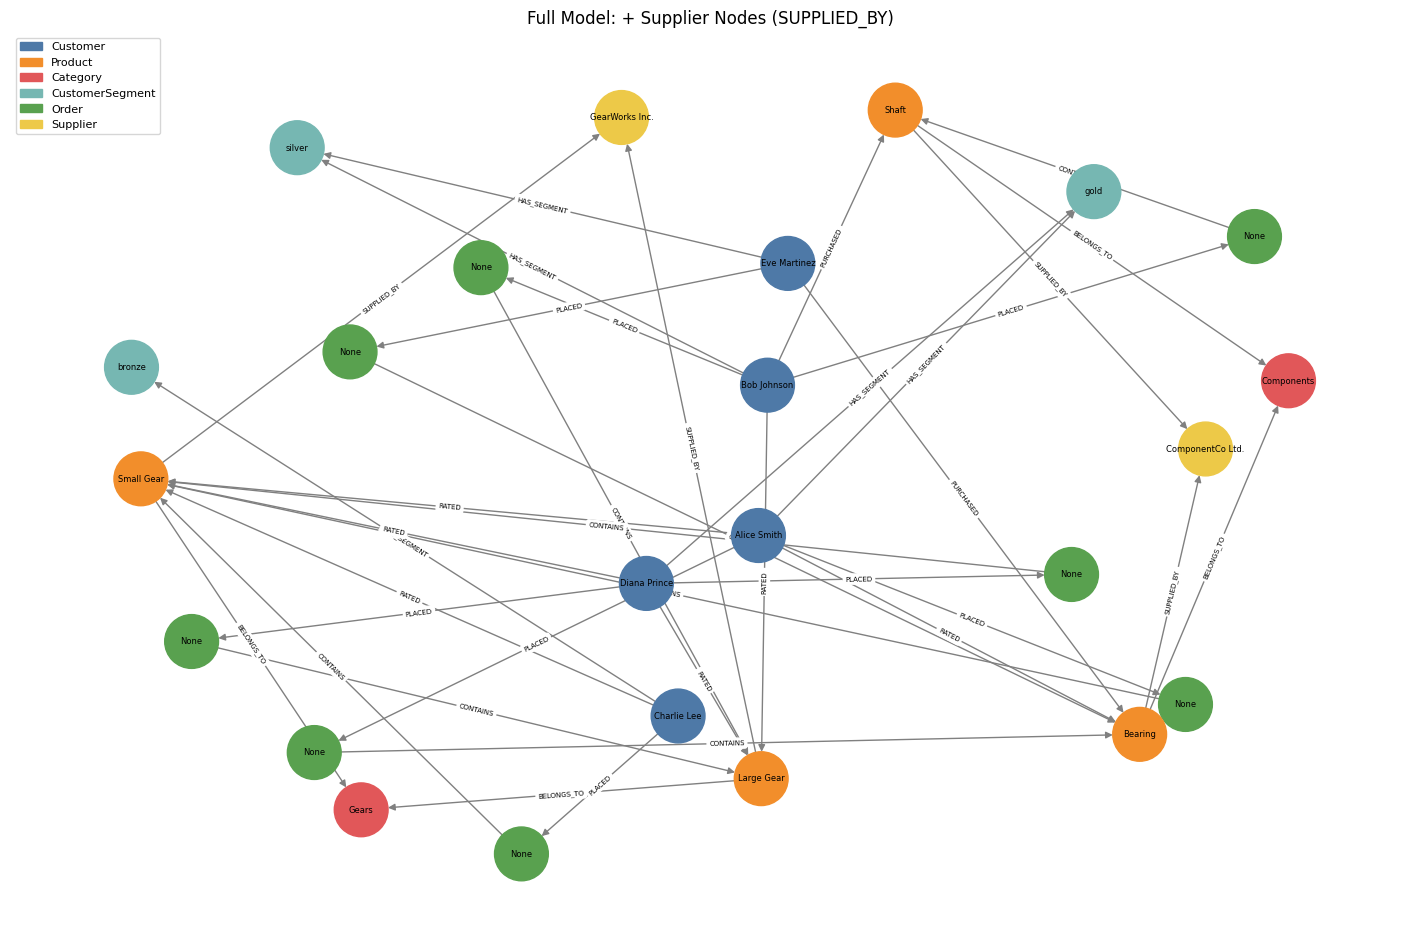

In [15]:
# Visualize the full model with Supplier nodes
G = nx.DiGraph()

with driver.session() as session:
    nodes = session.run("MATCH (n) RETURN coalesce(n.id, n.name) AS id, n.name AS name, labels(n)[0] AS label")
    for rec in nodes:
        G.add_node(rec['id'], label=rec['label'], name=rec['name'])

    edges = session.run("""
        MATCH (a)-[r]->(b)
        RETURN coalesce(a.id, a.name) AS src, coalesce(b.id, b.name) AS tgt, type(r) AS rel
    """)
    for rec in edges:
        G.add_edge(rec['src'], rec['tgt'], rel=rec['rel'])

color_map = {'Customer': '#4e79a7', 'Product': '#f28e2b', 'Category': '#e15759',
             'CustomerSegment': '#76b7b2', 'Order': '#59a14f', 'Supplier': '#edc948'}
colors = [color_map.get(G.nodes[n].get('label'), '#ccc') for n in G.nodes]
labels = {n: G.nodes[n].get('name', n) for n in G.nodes}
edge_labels = {(u, v): d['rel'] for u, v, d in G.edges(data=True)}

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42, k=1.5)
nx.draw(G, pos, labels=labels, node_color=colors, node_size=1500,
        font_size=6, arrows=True, edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=5)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
plt.legend(handles=legend_patches, loc='upper left', fontsize=8)
plt.title("Full Model: + Supplier Nodes (SUPPLIED_BY)")
plt.show()

#### Task 7: Supplier Performance Analysis

Now we can analyze supplier performance using our refactored graph.

In [16]:
# Supplier performance query
### BEGIN SOLUTION
supplier_performance_query = """
MATCH (s:Supplier)<-[:SUPPLIED_BY]-(p:Product)
OPTIONAL MATCH (o:Order)-[cont:CONTAINS]->(p)
OPTIONAL MATCH ()-[r:RATED]->(p)
RETURN s.name AS supplier,
       count(DISTINCT p) AS product_count,
       count(DISTINCT o) AS order_count,
       avg(r.score) AS avg_rating,
       sum(cont.quantity) AS total_units_sold
ORDER BY total_units_sold DESC
"""
### END SOLUTION

with driver.session() as session:
    result = session.run(supplier_performance_query)
    records = list(result)
    if records:
        df = pd.DataFrame([record.values() for record in records], columns=records[0].keys())
        print("Supplier Performance Analysis:")
        print(df)
    else:
        print("No results")

Supplier Performance Analysis:
           supplier  product_count  order_count  avg_rating  total_units_sold
0    GearWorks Inc.              2            5    4.384615                57
1  ComponentCo Ltd.              2            3    4.000000                24


## Step 9: Testing Relationship Type Importance

Let's demonstrate why specifying relationship types matters. Relationship types should be **verb phrases** that describe the action or connection between nodes.

Recall from the course: in graph databases, relationships are first-class data objects — they are stored directly, have direction and type, and can carry properties. Because graph queries use pattern matching (e.g., `MATCH (c)-[:PURCHASED]->(p)`), the relationship type name directly impacts both **readability** (can someone understand what the query does?) and **maintainability** (can someone extend or debug it later?).

Bad naming makes queries ambiguous and the graph harder to evolve. Good naming makes the graph self-documenting.

In [17]:
# Relationship Type Naming — Why It Matters
# In graph databases, relationships are first-class data objects
# (unlike relational DBs where relationships are implied via JOINs).
# Clear naming makes queries self-documenting and the graph maintainable.

print("=" * 60)
print("WHY RELATIONSHIP TYPE NAMING MATTERS")
print("=" * 60)

print("\n BAD RELATIONSHIP NAMING:")
print("   Customer -[HAS]-> Product")
print("   Customer -[IS]-> Product")
print("   Customer -[RELATED]-> Product")
print("   → Ambiguous: Does the customer own it? Purchased it? Want it?")
print("   → Hard to maintain and extend\n")

print("GOOD RELATIONSHIP NAMING (verb phrases):")
print("   Customer -[PURCHASED]-> Product   (indicates a transaction)")
print("   Customer -[RATED]-> Product       (indicates a review)")
print("   Customer -[INTERESTED_IN]-> Product (indicates browsing/wish list)")
print("   Product  -[BELONGS_TO]-> Category  (indicates classification)")
print("   Product  -[SUPPLIED_BY]-> Supplier (indicates supply chain)")
print("   Customer -[PLACED]-> Order         (indicates order creation)")
print("   Order    -[CONTAINS]-> Product     (indicates order contents)")
print("   → Clear intent, self-documenting, maintainable\n")

print("COMPARISON WITH SQL:")
print("   In SQL, relationships are implicit — reconstructed via JOINs.")
print("   In graphs, relationships are stored directly and traversed.")
print("   → Clear naming means the query reads like a sentence:")
print('   MATCH (c:Customer)-[:PURCHASED]->(p:Product)-[:BELONGS_TO]->(cat:Category)')
print('   "Find a Customer who PURCHASED a Product that BELONGS_TO a Category"\n')

print("BEST PRACTICE: Relationship types should be VERB PHRASES")
print("describing the action or connection between nodes!")

WHY RELATIONSHIP TYPE NAMING MATTERS

 BAD RELATIONSHIP NAMING:
   Customer -[HAS]-> Product
   Customer -[IS]-> Product
   Customer -[RELATED]-> Product
   → Ambiguous: Does the customer own it? Purchased it? Want it?
   → Hard to maintain and extend

GOOD RELATIONSHIP NAMING (verb phrases):
   Customer -[PURCHASED]-> Product   (indicates a transaction)
   Customer -[RATED]-> Product       (indicates a review)
   Customer -[INTERESTED_IN]-> Product (indicates browsing/wish list)
   Product  -[BELONGS_TO]-> Category  (indicates classification)
   Product  -[SUPPLIED_BY]-> Supplier (indicates supply chain)
   Customer -[PLACED]-> Order         (indicates order creation)
   Order    -[CONTAINS]-> Product     (indicates order contents)
   → Clear intent, self-documenting, maintainable

COMPARISON WITH SQL:
   In SQL, relationships are implicit — reconstructed via JOINs.
   In graphs, relationships are stored directly and traversed.
   → Clear naming means the query reads like a sentence:


## Step 10: Summary - Design Patterns Comparison

Let's visualize and compare the different models we've created.

In [18]:
# Final Graph Statistics — comparing the design patterns we've built:
# 1. Simple/Denormalized: Customer, Product nodes with PURCHASED/RATED relationships
# 2. Hub Nodes (Normalization): Category, CustomerSegment nodes with BELONGS_TO/HAS_SEGMENT
# 3. Intermediate Nodes: Order nodes with PLACED/CONTAINS relationships
# 4. Refactoring: Supplier nodes with SUPPLIED_BY relationships

stats_query = """
MATCH (n)
RETURN labels(n)[0] AS node_type, count(*) AS count
ORDER BY node_type
"""

with driver.session() as session:
    result = session.run(stats_query)
    records = list(result)
    if records:
        df = pd.DataFrame([record.values() for record in records], columns=['Node Type', 'Count'])
        print("Final Graph Statistics — All Design Patterns Combined:")
        print(df)
        print(f"\nTotal nodes: {df['Count'].sum()}")
    else:
        print("No results")

# Relationship statistics — each relationship type maps to a design pattern
rel_stats_query = """
MATCH ()-[r]->()
RETURN type(r) AS rel_type, count(*) AS count
ORDER BY count DESC
"""

with driver.session() as session:
    result = session.run(rel_stats_query)
    records = list(result)
    if records:
        df = pd.DataFrame([record.values() for record in records], columns=['Relationship Type', 'Count'])
        print("\nRelationship Statistics:")
        print(df)
        print(f"Total relationships: {df['Count'].sum()}")
        print("\nRelationship types by pattern:")
        print("  Simple/Denormalized: PURCHASED, RATED")
        print("  Hub Nodes:          BELONGS_TO, HAS_SEGMENT")
        print("  Intermediate Nodes: PLACED, CONTAINS")
        print("  Refactoring:        SUPPLIED_BY")
    else:
        print("No results")

Final Graph Statistics — All Design Patterns Combined:
         Node Type  Count
0         Category      2
1         Customer      5
2  CustomerSegment      3
3            Order      8
4          Product      4
5         Supplier      2

Total nodes: 24

Relationship Statistics:
  Relationship Type  Count
0         PURCHASED      8
1            PLACED      8
2          CONTAINS      8
3             RATED      6
4       HAS_SEGMENT      5
5        BELONGS_TO      4
6       SUPPLIED_BY      4
Total relationships: 43

Relationship types by pattern:
  Simple/Denormalized: PURCHASED, RATED
  Hub Nodes:          BELONGS_TO, HAS_SEGMENT
  Intermediate Nodes: PLACED, CONTAINS
  Refactoring:        SUPPLIED_BY


## Summary: Key Lessons from This Exercise

Great work getting through the exercise! Let's review some important things we've learned:

### 1. **Simple / Denormalized Model** (Step 4)
We started with `create_simple_model()` — a denormalized graph with `Customer` and `Product` nodes connected by `PURCHASED` and `RATED` relationships. Purchase metadata (date, quantity) and rating metadata (score, text) live directly on the relationships as properties. This is graph denormalization: data that is always accessed together is stored on the relationship, avoiding extra hops.

### 2. **Hub Node Pattern / Normalization** (Step 5)
In `create_enhanced_model()`, we added `Category` and `CustomerSegment` as hub nodes — shared connection points that enable efficient aggregation. `Product -[:BELONGS_TO]-> Category` and `Customer -[:HAS_SEGMENT]-> CustomerSegment` let us query "top products in Gears" or "gold customer purchasing patterns" by traversing to the hub node instead of filtering by property values across all nodes.

### 3. **Intermediate Nodes** (Step 6)
In `add_order_nodes()`, we promoted the `PURCHASED` relationship into an `Order` node: `Customer -[:PLACED]-> Order -[:CONTAINS]-> Product`. This gave us product affinity analysis (Task 3), customer lifetime value calculation (Task 4), and the ability to extend Orders with payments, shipments, or returns independently.

### 4. **Query-Driven Design** (Step 7)
We demonstrated that design patterns serve specific query needs:
- **Category hub query** (Task 1): Products in 'Gears' with average ratings — efficient because of the `Category` hub node
- **Segment analysis** (Task 2): Gold customer purchasing patterns — traverses `CustomerSegment → Customer → Order → Product → Category`
- **Product affinity** (Task 3): Co-purchased products — only possible because of `Order` intermediate nodes
- **Customer lifetime value** (Task 4): Total spending per customer — uses both hub nodes and intermediate nodes

Query performance in graphs is proportional to **traversal length** (number of hops), not dataset size — so each pattern is designed to keep common query paths short.

### 5. **Refactoring / Flexible Data Model** (Step 8)
In `add_supplier_network()`, we added `Supplier` nodes and `SUPPLIED_BY` relationships without modifying any existing data — no `ALTER TABLE`, no schema migration. We then immediately queried supplier performance (Task 5) by traversing `Supplier → Product → Order`. This demonstrates the flexible data model: structure emerges and evolves as data is created.

### 6. **Relationship Type Naming** (Step 9)
We used verb phrases for every relationship type in the exercise: `PURCHASED`, `RATED`, `BELONGS_TO`, `HAS_SEGMENT`, `PLACED`, `CONTAINS`, `SUPPLIED_BY`. Each relationship reads naturally in a Cypher query — e.g., `(c:Customer)-[:PLACED]->(o:Order)-[:CONTAINS]->(p:Product)` reads as "a Customer who PLACED an Order that CONTAINS a Product."

### 7. **Normalization vs. Denormalization Trade-offs**

| **What we denormalized** | **What we normalized** |
|---|---|
| Purchase date/quantity on `PURCHASED` relationship | `Category` hub nodes (avoid duplicating category names) |
| Rating score/text on `RATED` relationship | `CustomerSegment` hub nodes (enable segment-based queries) |
| Order quantity on `CONTAINS` relationship | `Order` intermediate nodes (enable affinity and CLV queries) |
| | `Supplier` hub nodes (enable supplier analytics) |

**The key signal:** If normalizing would add hops to your most common queries without enabling new query patterns, denormalize instead. If the same data would be duplicated across many nodes, normalize.